In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Perceptron Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)

class Perceptron :
    def __init__(self, n_iter=50, eta=0.01, random_state=1):
        self.n_iter = n_iter
        self.eta = eta
        self.random_state = random_state


    def fit(self, X, y):
        self.b_ = 0.0
        self.errors_ = []

        rgen = np.random.default_rng(self.random_state)
        self.w_ = rgen.normal(loc=0, scale=0.3, size=X.shape[1])
        # self.w_ = np.zeros(X.shape[1])

        for i in range(self.n_iter):
            errors = 0
            for xi,yi in zip(X,y) :
                y_pdt = self.predict(xi)
                delta = (yi - y_pdt) * self.eta
                
                self.b_ += delta
                self.w_ += (delta * xi)

                if yi != y_pdt:
                    errors += 1  
            
            self.errors_.append(errors)
    
    def predict(self, xi):
        temp = np.dot(xi, self.w_) + self.b_
        return np.where(temp >= 0.0,1,0)
        

In [3]:
# function for plotting decision regions
def plot_decision_regions(X, y, model, resolution=0.01):
    
    # color map
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    markers = ('o', 's', '^', 'v', '<')
    colmap = ListedColormap(colors[:len(np.unique(y))])

    # creating grid
    h_min, h_max = X[:,0].min()-1, X[:,0].max()+1
    v_min, v_max = X[:,1].min()-1, X[:,1].max()+1

    hh, vv = np.meshgrid(np.arange(h_min, h_max, resolution), 
                         np.arange(v_min, v_max, resolution))
    grid = np.c_[hh.ravel(), vv.ravel()] #transpose the data into required format

    # predicting class for each grid point
    grid_col = model.predict(grid)
    grid_col = grid_col.reshape(hh.shape)

    # plot decision regions
    plt.contourf(hh, vv, grid_col, alpha=0.3, cmap=colmap)
    plt.xlim(h_min, h_max)
    plt.ylim(v_min, v_max)

    # plotting sample data points over the decision regions
    for i, val in enumerate(np.unique(y)):
        plt.scatter(X[y==val, 0], 
                    X[y==val, 1], 
                    c=colors[i], 
                    marker=markers[i],
                    label=f"Class {val}",
                    edgecolors='black')

    plt.legend()
    

In [4]:
# Importing and formatting the data
path = '../data/iris.data'
data = pd.read_csv(path, header=None, encoding='utf-8')
print(data.head())

# setting up input and output
X = data.iloc[0:100, [0,2]].values
print(X[:5])

y = data.iloc[0:100, 4]
y = np.where(y=='Iris-setosa', 1, 0)
print(y[:5])
print(y[95:])


     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]
[1 1 1 1 1]
[0 0 0 0 0]


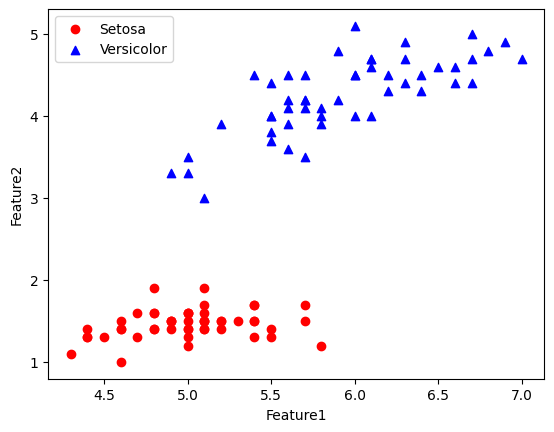

In [5]:
# Checking visually if the data is lineary separable
plt.scatter(X[0:50, 0], X[0:50, 1], marker='o', color='red', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], marker='^', color='blue', label='Versicolor')

plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.legend(loc='upper left')
plt.show()

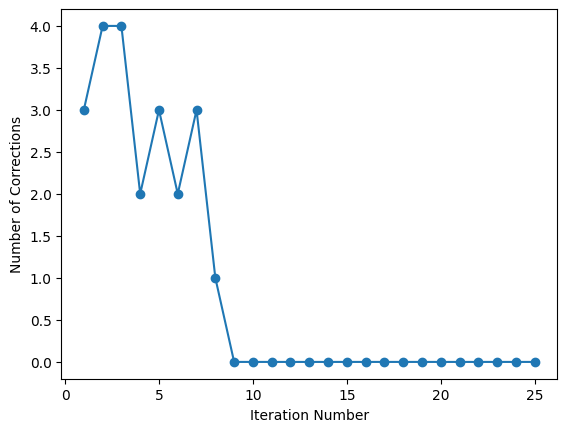

In [6]:
# fitting our data
ppn = Perceptron(n_iter=25,eta=0.01)
ppn.fit(X,y)

plt.plot(range(1,ppn.n_iter+1),ppn.errors_, marker='o')
plt.xlabel("Iteration Number")
plt.ylabel("Number of Corrections")
plt.show()

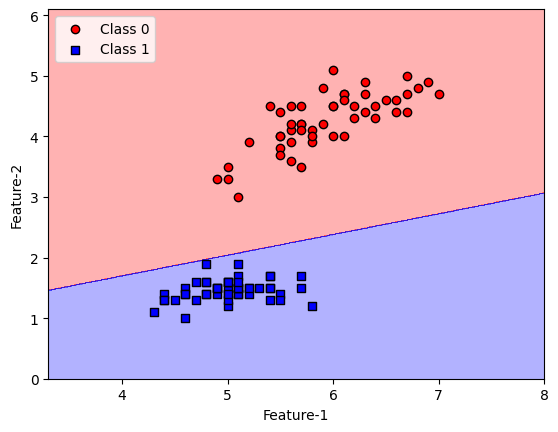

In [7]:
# plot decision regions and overlay the actual data over it 
plot_decision_regions(X,y,ppn)
plt.xlabel("Feature-1")
plt.ylabel("Feature-2")
plt.legend(loc="upper left")
plt.show()